In [1]:
#import relevant libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from collections import defaultdict
from matplotlib.patches import Circle
import matplotlib.font_manager as fm

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# File processing
workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = homecomp

filepath = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\3. Compiled\\"
openPath = specifiedpath + filepath
files2 = os.listdir(openPath)

In [5]:
# Set up Inter font
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

## formulas

In [7]:
def pergenotypeplotting_deltag(openPath, files2, k): 
    metricname = pd.DataFrame()
    singlemeandiff = pd.DataFrame()
    
    for f in files2:
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(" allstats.csv", "").replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        
        # Create dataframes directly in one step
        samplefile = pd.DataFrame({
            'bootstrap': newfile2read[k+"_bootstrap"],
            'deltag': newfile2read[k+"_deltag"],
            'Cross': cross,
            'metric': k,
            'samplesize': newfile2read['Sample_size']
        })
        
        singlemeans = pd.DataFrame({
            'mean': samplefile['deltag'].unique(),
            'cross': cross,
            'samplesize': newfile2read['Sample_size'].unique(),
            'err': samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))
        })
        

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

def pergenotypeplotting_hedgesg(openPath, files2, k): 
    metricname = pd.DataFrame()
    singlemeandiff = pd.DataFrame()
    
    for f in files2:
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(" allstats.csv", "").replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        
        # Create dataframes directly in one step
        samplefile = pd.DataFrame({
            'bootstrap': newfile2read[k+"_bootstrap"],
            'Hedgesg': newfile2read[k+"_Hedgesg"],
            'Cross': cross,
            'metric': k,
            'samplesize': newfile2read['Sample_size']
        })
        
        singlemeans = pd.DataFrame({
            'mean': samplefile['Hedgesg'].unique(),
            'cross': cross,
            'samplesize': newfile2read['Sample_size'].unique(),
            'err': samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))
        })

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

# TS-ER

In [6]:
files3 = ['nSyb x eOPN3 allstats.csv','nSyb x eOPN3-TS-ER(iii)M4 allstats.csv', 
          '46416jus x eOPN3 allstats.csv', '46416jus x eOPN3-TS-ER allstats.csv',
          'Cha-6793 x eOPN3 allstats.csv', 'Cha-6793 x eOPN3-TS-ER allstats.csv',
 'elav x eOPN3 allstats.csv', 'elav x eOPN3-TS-ER allstats.csv',
 'vGAT x eOPN3 allstats.csv', 'vGAT x eOPN3-TS-ER allstats.csv'
]

files3 = ['elav x ACR [ATR] allstats.csv',
 'elav x eOPN3 allstats.csv'

]

# files3 = ['Cha x eOPN3 allstats.csv',
#  'vGAT x eOPN3 allstats.csv', 
# 'nsyb x eOPN3 allstats.csv'
# ]

# files3 = ['OK371 x ACR allstats.csv',
#  'OK371 x eOPN3 allstats.csv',
#  'OK371 x eOPN3-galphai allstats.csv',
#  'OK371 x eOPN3-galphao allstats.csv'
#  ]


# files3 = ['Piezo x ACR allstats.csv',
#  'Piezo x eOPN3 allstats.csv',
#  'Piezo x eOPN3-galphai allstats.csv',
#  'Piezo x eOPN3-galphao allstats.csv']


# files3 = ['nsyb x eOPN3 allstats.csv',
#  'nsyb x PdCO [B] allstats.csv',
#   'Cha x eOPN3 allstats.csv',
#  'Cha x PdCO allstats.csv',]

In [ ]:


def forestplot(metricname, singlemeandiff, gridkey):
    from matplotlib.patches import Ellipse
    import textwrap
    # Setup
    fig = plt.figure(figsize=(8, 5))
    unique_crosses = singlemeandiff['cross'].unique()
    n_crosses = len(unique_crosses)
    padding = 0.7
    violin_color = "#3C9A29"
    
    # Create subplots
    ax_main = plt.subplot2grid((6, 1), (0, 0), rowspan=4)
    ax_table = plt.subplot2grid((6, 1), (4, 0), rowspan=1, sharex=ax_main)
    
    # Extract drivers and responders
    drivers = [cross.split(' ')[0] for cross in unique_crosses]
    responders = [cross.split(' ')[-1] for cross in unique_crosses]
    
    # Main plot: Create violin plots and error bars
    for i, (cross, mean, err) in enumerate(zip(singlemeandiff['cross'], singlemeandiff['mean'], singlemeandiff['err'])):
        # Violin plot
        cross_data = metricname[metricname['Cross'] == cross]['bootstrap']
        parts = ax_main.violinplot([cross_data], positions=[i], widths=0.6, 
                                 showmeans=False, showmedians=False, showextrema=False)
        
        # Style violin as right half only
        for pc in parts['bodies']:
            pc.set_facecolor(violin_color)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], i)
        
        # Error bar and text
        ax_main.errorbar(i, mean, yerr=err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        ax_main.text(i - 0.1, mean, f'{mean:.2f}', ha='right', va='center', 
                    fontsize=10, color=violin_color, fontweight='bold')
    
    # Format main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax_main.set_ylabel("Δg of " + metricname['metric'].unique()[0], fontsize=12)
    ax_main.set_ylim(-4.5, 1.2)
    ax_main.set_xlim(-padding, n_crosses - 1 + padding)
    ax_main.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax_main.spines[spine].set_visible(False)
    ax_main.set_xticks([])
    ax_main.set_xticklabels([])
    
    # Format table subplot
    ax_table.set_ylim(0, 1)
    gridkeylabel = textwrap.fill(gridkey, width=7)
    ax_table.set_ylabel(gridkeylabel, fontsize = 10, style = 'italic', labelpad = 15, rotation = 0, loc ='center')
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    
    # Draw grid
    first_grid, last_grid = -0.5, n_crosses - 0.5
    x_range = n_crosses - 1 + 2*padding
    
    # Horizontal lines
    for y in [0.2, 0.8]:
        ax_table.axhline(y=y, color='black', linewidth=1, 
                        xmin=(first_grid + padding) / x_range, 
                        xmax=(last_grid + padding) / x_range)
    
    # Vertical lines
    for i in range(n_crosses + 1):
        ax_table.axvline(x=i - 0.5, color='black', linewidth=1, ymin=0.2, ymax=0.8)
    
    # Add circles
    bbox = ax_table.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    radius_x = (10 / 72.0) / bbox.width * x_range / 2
    radius_y = (10 / 72.0) / bbox.height / 2
    
    for i, responder in enumerate(responders):
        if responder == gridkey:
            circle = Ellipse((i, 0.5), width=2*radius_x, height=2*radius_y, 
                           color='black', clip_on=False)
            ax_table.add_patch(circle)
    
    # Driver labels
    driver_groups = defaultdict(list)
    for i, driver in enumerate(drivers):
        driver_groups[driver].append(i)
    
    for driver, indices in driver_groups.items():
        if len(indices) > 1:
            x_start, x_end = min(indices) - 0.3, max(indices) + 0.3
            ax_table.plot([x_start, x_end], [0.05, 0.05], 'k-', linewidth=1)
            ax_table.text((x_start + x_end) / 2, -0.05, driver, ha='center', va='top', 
                         fontsize=10, style='italic')
    
    return fig

In [ ]:
# Generate plots
lstnamings = ['speed', 'height']

for n in lstnamings:
    dfmn, dfsmd = pergenotypeplotting(openPath, files3, n)
    g = forestplot(dfmn, dfsmd, "AsOPN3-TS-ER")
    mpl.rcParams['svg.fonttype'] = 'none'
    #g.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot of TS_ER " + n + ".svg", bbox_inches="tight") 
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\3. Compiled\\nSyb x eOPN3 allstats.csv'

# ACR or eOPN3


In [7]:
def forestplot_paired_phases(metricname_full, singlemeandiff_full, metricname_recovery, singlemeandiff_recovery, gridkey1, gridkey2):
    import textwrap
    from matplotlib.patches import Ellipse
    # Setup
    fig = plt.figure(figsize=(9, 5))
    
    # Get unique crosses and create paired positions
    unique_crosses_full = singlemeandiff_full['cross'].unique()
    unique_crosses_recovery = singlemeandiff_recovery['cross'].unique()
    
    # Match crosses between phases
    matched_crosses = []
    for cross_full in unique_crosses_full:
        # Find matching cross in recovery (remove phase suffix for matching)
        base_cross = cross_full.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '')
        for cross_recovery in unique_crosses_recovery:
            if cross_recovery.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '') == base_cross:
                matched_crosses.append((cross_full, cross_recovery, base_cross))
                break
    
    # Group by driver for labeling (but not for spacing)
    driver_groups = defaultdict(list)
    for i, (_, _, base_cross) in enumerate(matched_crosses):
        driver = base_cross.split(' x ')[0]
        driver_groups[driver].append(i)
    
    # Calculate positions with equal spacing for ALL genotype pairs
    n_pairs = len(matched_crosses)
    genotype_spacing = 1.5  # Equal distance between each genotype pair
    violin_color_full = "#43961C"
    violin_color_fulltext = "#2D6613"
    violin_color_recovery = "#727272"
    violin_color_recoverytext = "#242424"
    
    # Create subplots
    ax_main = plt.subplot2grid((6, 1), (0, 0), rowspan=4)
    ax_table = plt.subplot2grid((6, 1), (4, 0), rowspan=2, sharex=ax_main)
    
    # Create positions with equal spacing for all genotype pairs
    pair_positions = []
    full_positions = []
    recovery_positions = []
    
    for i in range(n_pairs):
        center_pos = i * genotype_spacing
        full_pos = center_pos - 0.25
        recovery_pos = center_pos + 0.25
        
        pair_positions.append(center_pos)
        full_positions.append(full_pos)
        recovery_positions.append(recovery_pos)
    
    # Main plot: Create paired violin plots
    for i, (cross_full, cross_recovery, base_cross) in enumerate(matched_crosses):
        full_pos = full_positions[i]
        recovery_pos = recovery_positions[i]
        
        # Get data for both phases
        full_data = metricname_full[metricname_full['Cross'] == cross_full]['bootstrap']
        recovery_data = metricname_recovery[metricname_recovery['Cross'] == cross_recovery]['bootstrap']
        
        full_mean = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['mean'].iloc[0]
        full_err = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['err'].iloc[0]
        
        recovery_mean = singlemeandiff_recovery[singlemeandiff_recovery['cross'] == cross_recovery]['mean'].iloc[0]
        recovery_err = singlemeandiff_recovery[singlemeandiff_recovery['cross'] == cross_recovery]['err'].iloc[0]
        
        # Violin plots
        # Dark-full phase
        parts_full = ax_main.violinplot([full_data], positions=[full_pos], widths=0.4, 
                                       showmeans=False, showmedians=False, showextrema=False)
        for pc in parts_full['bodies']:
            pc.set_facecolor(violin_color_full)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], full_pos)
        
        # Dark-recovery phase
        parts_recovery = ax_main.violinplot([recovery_data], positions=[recovery_pos], widths=0.4, 
                                           showmeans=False, showmedians=False, showextrema=False)
        for pc in parts_recovery['bodies']:
            pc.set_facecolor(violin_color_recovery)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], recovery_pos)
        
        # Error bars and mean dots
        ax_main.errorbar(full_pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        ax_main.errorbar(recovery_pos, recovery_mean, yerr=recovery_err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        
        # Connecting line between means (faded)
        ax_main.plot([full_pos, recovery_pos], [full_mean, recovery_mean], 
                    color='black', alpha=0.4, linewidth=2, linestyle='-')
        
        # Mean value labels with Inter font
        ax_main.text(full_pos - 0.1, full_mean, f'{full_mean:.2f}', ha='right', va='center', 
                    fontsize=9, color=violin_color_fulltext, fontweight='bold', fontfamily='Inter')
        ax_main.text(recovery_pos + 0.1, recovery_mean, f'{recovery_mean:.2f}', ha='left', va='center', 
                    fontsize=9, color=violin_color_recoverytext, fontweight='bold', fontfamily='Inter')
    
    # Format main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax_main.set_ylabel("Δg of " + metricname_full['metric'].unique()[0] , fontweight = 'bold',
                      fontsize=11, fontfamily='Inter')
    ax_main.set_ylim(-5.0, 1.2)
    
    # Set x-axis limits with padding
    if pair_positions:
        ax_main.set_xlim(min(pair_positions) - 1.0, max(pair_positions) + 1.0)
    
    ax_main.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax_main.spines[spine].set_visible(False)
    ax_main.set_xticks([])
    ax_main.set_xticklabels([])
    
    
    # Format table subplot
    ax_table.set_ylim(0, 1)
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    
    # Draw grid exactly like the original forestplot function
    if pair_positions:
        n_pairs = len(pair_positions)
        
        # Calculate grid boundaries (similar to original)
        first_grid = min(pair_positions) - 0.5
        last_grid = max(pair_positions) + 0.5
        x_range = max(pair_positions) - min(pair_positions) + 2.0
        
        # Horizontal lines (properly connected)
        for y in [0.2, 0.5, 0.8]:
            ax_table.axhline(y=y, color='black', linewidth=1, 
                            xmin=(first_grid - min(pair_positions) + 1.0) / x_range, 
                            xmax=(last_grid - min(pair_positions) + 1.0) / x_range)
            
    # Add phase labels with Inter font
    if pair_positions:
        ax_table.text((first_grid - min(pair_positions)/ x_range)-0.4, 0.92, 'DARK:LIGHT ON', ha='center', va='center', fontsize=10, 
                    color=violin_color_full, fontweight='bold', rotation=0, fontfamily='Inter')
        ax_table.text((first_grid - min(pair_positions) / x_range) + 1.4 , 0.92, 'DARK:RECOVERY', ha='center', va='center', fontsize=10, 
                    color=violin_color_recovery, fontweight='bold', rotation=0, fontfamily='Inter')
        
         # Solid line between the textson? (optional)
        line_start_x = (first_grid - min(pair_positions)/ x_range) + 0.3  # End of first text
        line_end_x = (first_grid - min(pair_positions) / x_range) + 0.6   # Start of second text
        ax_table.plot([line_start_x, line_end_x], [0.92, 0.92], 'k-', linewidth=1.5)
        
        # Vertical lines - following original pattern: n_pairs + 1 lines at positions pair_center ± 0.5
        for i in range(n_pairs + 1):
            if i == 0:
                x_pos = first_grid
            elif i == n_pairs:
                x_pos = last_grid
            else:
                # Position halfway between adjacent pair centers
                x_pos = (pair_positions[i-1] + pair_positions[i]) / 2
            
            ax_table.axvline(x=x_pos, color='black', linewidth=1, ymin=0.2, ymax=0.8)
        
        # Add perfectly round circles for genotype classification
        bbox = ax_table.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        radius_x = (10 / 72.0) / bbox.width * x_range / 2
        radius_y = (10 / 72.0) / bbox.height / 2
        
        # Extract drivers and responders for gridkey placement
        drivers = []
        responders = []
        for _, _, base_cross in matched_crosses:
            parts = base_cross.split(' x ')
            if len(parts) >= 2:
                drivers.append(parts[0])
                responders.append(parts[1])
        
        # Gridkey labels with Inter font
        gridkeylabel1 = textwrap.fill(gridkey1, width=7)
        ax_table.text(min(pair_positions) - 1.2, 0.35, gridkeylabel1, fontsize=10, fontfamily='Inter')
        
        gridkeylabel2 = textwrap.fill(gridkey2, width=7)
        ax_table.text(min(pair_positions) - 1.2, 0.65, gridkeylabel2, fontsize=10, fontfamily='Inter')
        
        # Place perfectly round circles based on responder genotype
        for i, responder in enumerate(responders):
            center_x = pair_positions[i]
            if gridkey1 in responder:
                # Use Ellipse with equal width/height for perfect circle
                circle = Ellipse((center_x, 0.35), width=2*radius_x, height=2*radius_y,
                                color='black', clip_on=False)
                ax_table.add_patch(circle)
            elif gridkey2 in responder:
                circle = Ellipse((center_x, 0.65), width=2*radius_x, height=2*radius_y,
                                color='black', clip_on=False)
                ax_table.add_patch(circle)
        
        # Driver labels (grouped) with Inter font
        line_offset = genotype_spacing * 0.4
        for driver, indices in driver_groups.items():
            if len(indices) > 0:
                x_positions = [pair_positions[i] for i in indices]
                x_start, x_end = min(x_positions) - line_offset, max(x_positions) + line_offset
                ax_table.plot([x_start, x_end], [0.05, 0.05], 'k-', linewidth=1)
                ax_table.text((x_start + x_end) / 2, -0.05, driver, ha='center', va='top', 
                             fontsize=10, style='italic', fontfamily='Inter')
    
    return fig

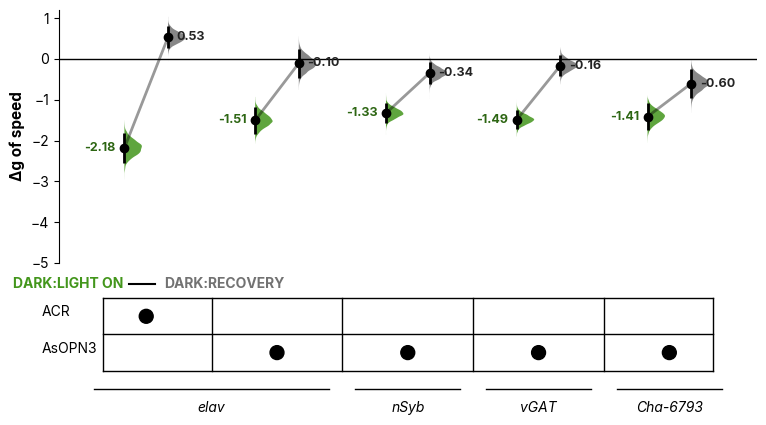

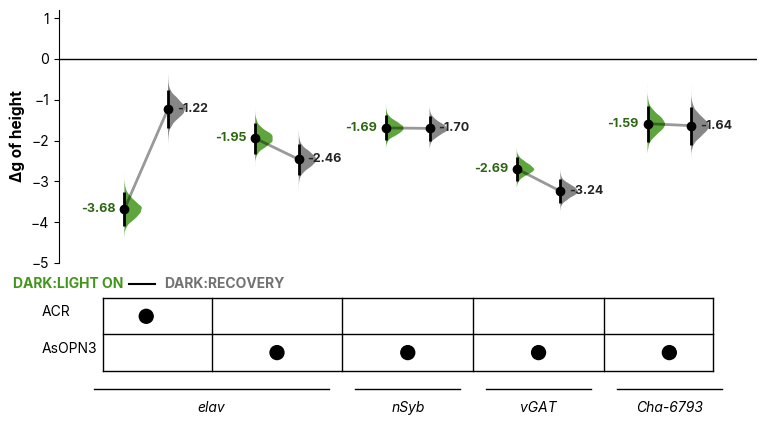

In [8]:
# Generate paired phase plots
lstnamings = ['speed', 'height']

##wt comparison
files_full = [f'elav x ACR [ATR] allstats_DARK_FULL_wtcomparison.csv', f'elav x eOPN3 allstats_DARK_FULL_wtcomparison.csv',           
              f'nSyb x eOPN3 allstats_DARK_FULL_wtcomparison.csv',
              f'vGAT x eOPN3 allstats_DARK_FULL_wtcomparison.csv', f'Cha-6793 x eOPN3 allstats_DARK_FULL_wtcomparison.csv']

files_recovery = [f'elav x ACR [ATR] allstats_DARK_RECOVERY_wtcomparison.csv', f'elav x eOPN3 allstats_DARK_RECOVERY_wtcomparison.csv',           
                  f'nSyb x eOPN3 allstats_DARK_RECOVERY_wtcomparison.csv',
                  f'vGAT x eOPN3 allstats_DARK_RECOVERY_wtcomparison.csv', f'Cha-6793 x eOPN3 allstats_DARK_RECOVERY_wtcomparison.csv']

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)
    dfmn_recovery, dfsmd_recovery = pergenotypeplotting_deltag(openPath, files_recovery, n)
    
    # Create paired plot
    g = forestplot_paired_phases(dfmn_full, dfsmd_full, dfmn_recovery, dfsmd_recovery, "AsOPN3", "ACR")
    mpl.rcParams['svg.fonttype'] = 'none' 
    #g.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot of ACR and AsOPN3 paired phases " + n + ".svg", bbox_inches="tight") 
    plt.show()

# Table for paired plot

In [27]:
def forestplot_paired_phases_table(metricname_full, singlemeandiff_full, metricname_recovery, singlemeandiff_recovery, gridkey1, gridkey2):

    import matplotlib.patches as patches
    from collections import defaultdict

    fig = plt.figure(figsize=(10, 6))  # Slightly taller to accommodate table
    
    
    # Get unique crosses and create paired positions
    unique_crosses_full = singlemeandiff_full['cross'].unique()
    unique_crosses_recovery = singlemeandiff_recovery['cross'].unique()
    
    # Match crosses between phases
    matched_crosses = []
    for cross_full in unique_crosses_full:
        # Find matching cross in recovery (remove phase suffix for matching)
        base_cross = cross_full.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '')
        for cross_recovery in unique_crosses_recovery:
            if cross_recovery.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '') == base_cross:
                matched_crosses.append((cross_full, cross_recovery, base_cross))
                break
    
    # Group by driver for labeling (but not for spacing)
    driver_groups = defaultdict(list)
    for i, (_, _, base_cross) in enumerate(matched_crosses):
        driver = base_cross.split(' x ')[0]
        driver_groups[driver].append(i)
    
    # Calculate positions with equal spacing for ALL genotype pairs
    n_pairs = len(matched_crosses)
    genotype_spacing = 1.5  # Equal distance between each genotype pair
    violin_color_full = "#2ECA13"
    violin_color_fulltext = "#4BAD1E"
    violin_color_recovery = "#727272"
    violin_color_recoverytext = "#242424"
    
    # Create subplots with improved layout - less white space at bottom
    ax_main = plt.subplot2grid((8, 1), (0, 0), rowspan=5)
    ax_table = plt.subplot2grid((8, 1), (5, 0), rowspan=3)
    
    # Create positions with equal spacing for all genotype pairs
    pair_positions = []
    full_positions = []
    recovery_positions = []
    
    for i in range(n_pairs):
        center_pos = i * genotype_spacing
        full_pos = center_pos - 0.25
        recovery_pos = center_pos + 0.25
        
        pair_positions.append(center_pos)
        full_positions.append(full_pos)
        recovery_positions.append(recovery_pos)
    
    # Main plot: Create paired violin plots (same as original)
    for i, (cross_full, cross_recovery, base_cross) in enumerate(matched_crosses):
        full_pos = full_positions[i]
        recovery_pos = recovery_positions[i]
        
        # Get data for both phases
        full_data = metricname_full[metricname_full['Cross'] == cross_full]['bootstrap']
        recovery_data = metricname_recovery[metricname_recovery['Cross'] == cross_recovery]['bootstrap']
        
        full_mean = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['mean'].iloc[0]
        full_err = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['err'].iloc[0]
        samplesize = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['samplesize'].iloc[0]
        
        recovery_mean = singlemeandiff_recovery[singlemeandiff_recovery['cross'] == cross_recovery]['mean'].iloc[0]
        recovery_err = singlemeandiff_recovery[singlemeandiff_recovery['cross'] == cross_recovery]['err'].iloc[0]

        
        # Violin plots
        # Dark-full phase
        parts_full = ax_main.violinplot([full_data], positions=[full_pos], widths=0.4, 
                                       showmeans=False, showmedians=False, showextrema=False)
        for pc in parts_full['bodies']:
            pc.set_facecolor(violin_color_full)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], full_pos)
        
        # Dark-recovery phase
        parts_recovery = ax_main.violinplot([recovery_data], positions=[recovery_pos], widths=0.4, 
                                           showmeans=False, showmedians=False, showextrema=False)
        for pc in parts_recovery['bodies']:
            pc.set_facecolor(violin_color_recovery)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], recovery_pos)
        
        # Error bars and mean dots
        ax_main.errorbar(full_pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        ax_main.errorbar(recovery_pos, recovery_mean, yerr=recovery_err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        
        # Connecting line between means (faded)
        ax_main.plot([full_pos, recovery_pos], [full_mean, recovery_mean], 
                    color='black', alpha=0.4, linewidth=2, linestyle='-')
        
        # Mean value labels 
        ax_main.text(full_pos - 0.1, full_mean, f'{full_mean:.2f}', ha='right', va='center', 
                    fontsize=13, color=violin_color_fulltext, fontweight='bold', fontfamily='Inter')
        ax_main.text(recovery_pos + 0.1, recovery_mean, f'{recovery_mean:.2f}', ha='left', va='center', 
                    fontsize=13, color=violin_color_recoverytext, fontweight='bold', fontfamily='Inter')
    
    # Format main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)

    #title
    ax_main.set_ylabel("Δg of " + metricname_full['metric'].unique()[0], fontweight='bold',
                      fontsize=16, fontfamily='Inter')
    ax_main.set_ylim(-5.0, 0)
    ax_main.set_yticks(np.arange(-5, 1.3, 1)) 
    ax_main.tick_params(axis='y', labelsize=14)
    # Set x-axis limits with padding
    if pair_positions:
        ax_main.set_xlim(min(pair_positions) - 1.0, max(pair_positions) + 1.0)
    
    ax_main.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax_main.spines[spine].set_visible(False)
    ax_main.set_xticks([])
    ax_main.set_xticklabels([])
    
    # Extract drivers and responders for table
    drivers = []
    responders = []
    for _, _, base_cross in matched_crosses:
        parts = base_cross.split(' x ')
        if len(parts) >= 2:
            drivers.append(parts[0])
            responders.append(parts[1])
    
    # Set tight table limits
    ax_table.set_xlim(min(pair_positions) - 1, max(pair_positions) + 1)
    max_y =1.0
    min_y = 0.0
    ax_table.set_ylim(min_y, max_y)
    
    # Add phase labels at the top with better positioning
    ax_table.text(min(pair_positions) - 0.7, max_y-0.1, 'DARK:LIGHT ON', ha='center', va='center', fontsize=12, 
                 color=violin_color_fulltext, fontweight='bold', rotation=0, fontfamily='Inter')
    ax_table.text(min(pair_positions) + 0.8, max_y-0.1, 'DARK:RECOVERY', ha='center', va='center', fontsize=12, 
                 color=violin_color_recoverytext, fontweight='bold', rotation=0, fontfamily='Inter')
    
    # Connecting line between phase labels
    ax_table.plot([min(pair_positions) - 0.08, min(pair_positions) + 0.13], [max_y-0.1, max_y-0.1], 'k-', linewidth=1.5)
    
    # Table structure - rectangles right next to each other (like create_table_plot)
    cell_width = genotype_spacing
    cell_height = 0.15
    cell_start = 0.65
    
    # Draw table grid with NO gaps between cells
    for i, center_pos in enumerate(pair_positions):
        rect1 = patches.Rectangle((center_pos - cell_width/2, cell_start), cell_width, cell_height, 
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect1)
        
        rect2 = patches.Rectangle((center_pos - cell_width/2, cell_start-cell_height), cell_width, cell_height,
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect2)
        
        rect3 = patches.Rectangle((center_pos - cell_width/2, cell_start-cell_height-cell_height), cell_width, cell_height,
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect3)
        
        # Add dots based on responder type
        if gridkey1 in responders[i]:
            ax_table.plot(center_pos, cell_start+(cell_height*0.5), 'ko', markersize=11)
        elif gridkey2 in responders[i]:
            ax_table.plot(center_pos, (cell_start-cell_height)+(cell_height*0.5), 'ko', markersize=11)
        
        # Add sample size to the 3rd row
        cross_full = matched_crosses[i][0]
        sample_size = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['samplesize'].iloc[0]
        ax_table.text(center_pos, (cell_start-cell_height-cell_height)+(cell_height*0.5), str(sample_size), 
                     ha='center', va='center', fontsize=13, fontfamily='Inter')

    
    # Add row labels
    ax_table.text(min(pair_positions) - 0.9, cell_start+(cell_height*0.5), gridkey1, ha='right', va='center', 
                 fontsize=13, fontfamily='Inter')
    ax_table.text(min(pair_positions) - 0.9, (cell_start-cell_height)+(cell_height*0.5), gridkey2, ha='right', va='center', 
                 fontsize=13, fontfamily='Inter')
    ax_table.text(min(pair_positions) - 0.9, (cell_start-cell_height-cell_height)+(cell_height*0.5), "N's", ha='right', va='center', 
                 fontsize=13, fontfamily='Inter')
    
    # Add driver labels WITH grouping lines (using original spacing)
    for driver, indices in driver_groups.items():
        if len(indices) > 0:
            x_positions = [pair_positions[i] for i in indices]
            x_start = min(x_positions) - (genotype_spacing * 0.4)
            x_end = max(x_positions) + (genotype_spacing * 0.4)
            y_pos = (cell_start-cell_height-cell_height) - (cell_height*0.25)
            
            # Draw horizontal line above driver name
            ax_table.plot([x_start, x_end], [y_pos, y_pos], 'k-', linewidth=1)
            # Center the driver name
            x_center = np.mean(x_positions)
            ax_table.text(x_center, y_pos-(cell_height*0.25), driver, ha='center', va='top', 
                            fontsize=10, style='italic', fontfamily='Inter')
   
    # Clean up table axes
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    mpl.rcParams['svg.fonttype'] = 'none' 
    # Apply tight layout to minimize white space
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Reduce bottom margin
    
    return fig

Creating table-based paired phases plot for speed...


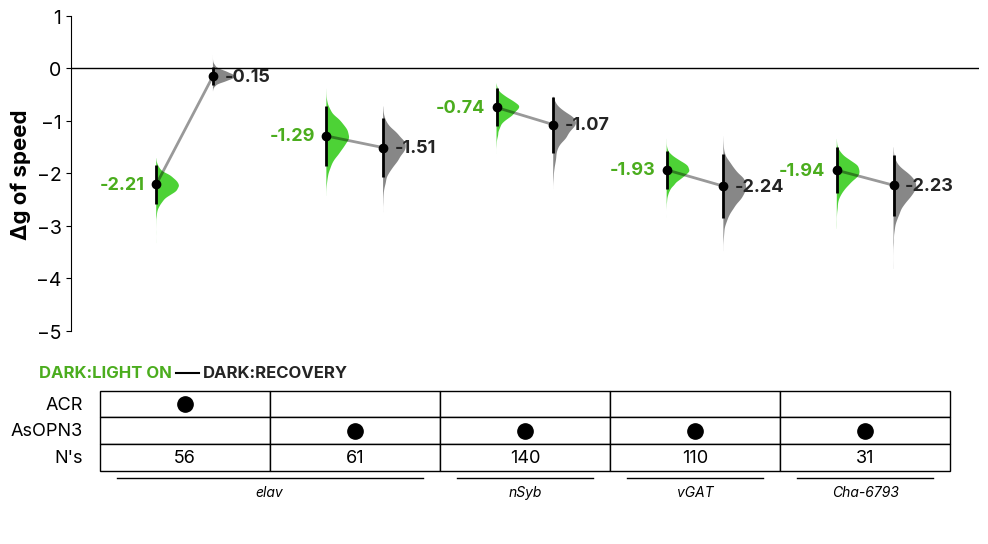

Creating table-based paired phases plot for height...


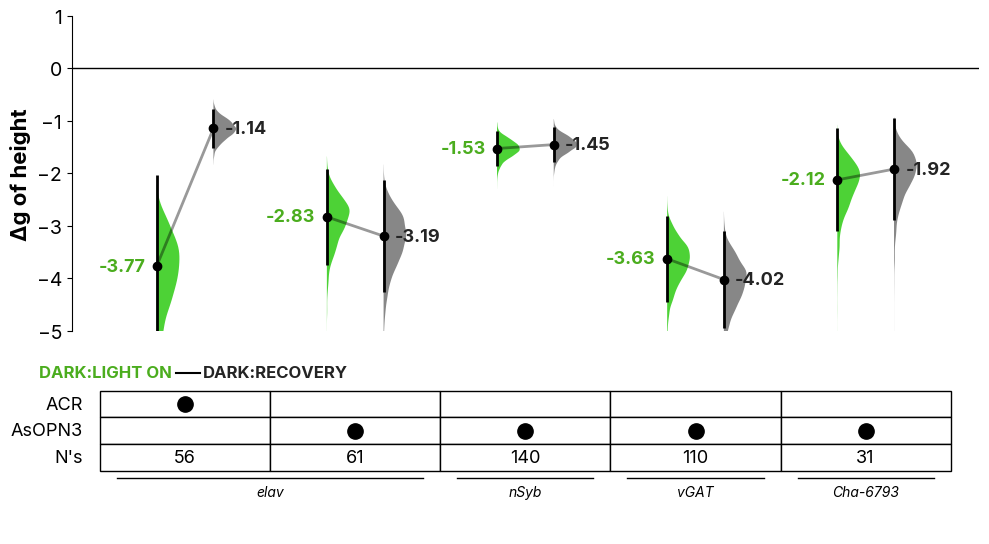

In [29]:
# Generate paired phase plots with TABLE format
lstnamings = ['speed', 'height']

##wt comparison
files_full = [f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 allstats_DARK_FULL.csv',           
              f'nSyb x eOPN3 allstats_DARK_FULL.csv',
              f'vGAT x eOPN3 allstats_DARK_FULL.csv', f'Cha-6793 x eOPN3 allstats_DARK_FULL.csv']

files_recovery = [f'elav x ACR [ATR] allstats_DARK_RECOVERY.csv', f'elav x eOPN3 allstats_DARK_RECOVERY.csv',           
                  f'nSyb x eOPN3 allstats_DARK_RECOVERY.csv',
                  f'vGAT x eOPN3 allstats_DARK_RECOVERY.csv', f'Cha-6793 x eOPN3 allstats_DARK_RECOVERY.csv']

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_hedgesg(openPath, files_full, n)
    dfmn_recovery, dfsmd_recovery = pergenotypeplotting_hedgesg(openPath, files_recovery, n)
    
    # Create paired plot with TABLE format
    print(f"Creating table-based paired phases plot for {n}...")
    g_table = forestplot_paired_phases_table(dfmn_full, dfsmd_full, dfmn_recovery, dfsmd_recovery, "ACR", "AsOPN3")
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    g_table.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_paired_phases_" + n + ".svg", bbox_inches="tight") 
    plt.show()


## table for single phase

In [8]:
def forestplot_single_phase_table(metricname_full, singlemeandiff_full, gridkey1, gridkey2):

    import matplotlib.patches as patches
    from collections import defaultdict

    fig = plt.figure(figsize=(10, 6))  # Slightly taller to accommodate table
    
    # Get unique crosses
    unique_crosses_full = singlemeandiff_full['cross'].unique()
    
    # Match crosses - just use the full phase data
    matched_crosses = []
    for cross_full in unique_crosses_full:
        # Remove phase suffix for base cross name
        base_cross = cross_full.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '')
        matched_crosses.append((cross_full, base_cross))
    
    # Group by driver for labeling (but not for spacing)
    driver_groups = defaultdict(list)
    for i, (_, base_cross) in enumerate(matched_crosses):
        driver = base_cross.split(' x ')[0]
        driver_groups[driver].append(i)
    
    # Calculate positions with equal spacing for ALL genotypes
    n_genotypes = len(matched_crosses)
    genotype_spacing = 1.5  # Equal distance between each genotype
    violin_color_full = "#21900D"
    violin_color_fulltext = "#3B8A17"
    
    # Create subplots with improved layout - less white space at bottom
    ax_main = plt.subplot2grid((8, 1), (0, 0), rowspan=5)
    ax_table = plt.subplot2grid((8, 1), (5, 0), rowspan=3)
    
    # Create positions with equal spacing for all genotypes
    genotype_positions = []
    
    for i in range(n_genotypes):
        center_pos = i * genotype_spacing
        genotype_positions.append(center_pos)
    
    # Main plot: Create single violin plots
    for i, (cross_full, base_cross) in enumerate(matched_crosses):
        pos = genotype_positions[i]
        
        # Get data for dark:light on phase
        full_data = metricname_full[metricname_full['Cross'] == cross_full]['bootstrap']
        
        full_mean = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['mean'].iloc[0]
        full_err = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['err'].iloc[0]
        samplesize = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['samplesize'].iloc[0]
        
        # Violin plot - Dark:light on phase
        parts_full = ax_main.violinplot([full_data], positions=[pos], widths=0.6, 
                                       showmeans=False, showmedians=False, showextrema=False)
        for pc in parts_full['bodies']:
            pc.set_facecolor(violin_color_full)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], pos)
        
        # Error bar and mean dot
        ax_main.errorbar(pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        
        # Mean value label 
        ax_main.text(pos - 0.1, full_mean, f'{full_mean:.2f}', ha='right', va='center', 
                    fontsize=13, color=violin_color_fulltext, fontweight='bold', fontfamily='Inter')
    
    # Format main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)

    #title
    ax_main.set_ylabel("Δg of " + metricname_full['metric'].unique()[0], fontweight='bold',
                      fontsize=16, fontfamily='Inter')
    ax_main.set_ylim(-5.0, 0)
    ax_main.set_yticks(np.arange(-5, 1.3, 1)) 
    ax_main.tick_params(axis='y', labelsize=14)
    # Set x-axis limits with padding
    if genotype_positions:
        ax_main.set_xlim(min(genotype_positions) - 1.0, max(genotype_positions) + 1.0)
    
    ax_main.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax_main.spines[spine].set_visible(False)
    ax_main.set_xticks([])
    ax_main.set_xticklabels([])
    
    # Extract drivers and responders for table
    drivers = []
    responders = []
    for _, base_cross in matched_crosses:
        parts = base_cross.split(' x ')
        if len(parts) >= 2:
            drivers.append(parts[0])
            responders.append(parts[1])
    
    # Set tight table limits
    ax_table.set_xlim(min(genotype_positions) - 1, max(genotype_positions) + 1)
    max_y = 1.0
    min_y = 0.0
    ax_table.set_ylim(min_y, max_y)
    
    # Table structure - rectangles right next to each other
    cell_width = genotype_spacing
    cell_height = 0.15
    cell_start = 0.65
    
    # Draw table grid with NO gaps between cells
    for i, center_pos in enumerate(genotype_positions):
        rect1 = patches.Rectangle((center_pos - cell_width/2, cell_start), cell_width, cell_height, 
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect1)
        
        rect2 = patches.Rectangle((center_pos - cell_width/2, cell_start-cell_height), cell_width, cell_height,
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect2)
        
        rect3 = patches.Rectangle((center_pos - cell_width/2, cell_start-cell_height-cell_height), cell_width, cell_height,
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect3)
        
        # Add dots based on responder type
        if gridkey1 in responders[i]:
            ax_table.plot(center_pos, cell_start+(cell_height*0.5), 'ko', markersize=11)
        elif gridkey2 in responders[i]:
            ax_table.plot(center_pos, (cell_start-cell_height)+(cell_height*0.5), 'ko', markersize=11)
        
        # Add sample size to the 3rd row
        cross_full = matched_crosses[i][0]
        sample_size = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['samplesize'].iloc[0]
        ax_table.text(center_pos, (cell_start-cell_height-cell_height)+(cell_height*0.5), str(sample_size), 
                     ha='center', va='center', fontsize=13, fontfamily='Inter')

    
    # Add row labels
    ax_table.text(min(genotype_positions) - 0.9, cell_start+(cell_height*0.5), gridkey1, ha='right', va='center', 
                 fontsize=13, fontfamily='Inter')
    ax_table.text(min(genotype_positions) - 0.9, (cell_start-cell_height)+(cell_height*0.5), gridkey2, ha='right', va='center', 
                 fontsize=13, fontfamily='Inter')
    ax_table.text(min(genotype_positions) - 0.9, (cell_start-cell_height-cell_height)+(cell_height*0.5), "N's", ha='right', va='center', 
                 fontsize=13, fontfamily='Inter')
    
    # Add driver labels WITH grouping lines (using original spacing)
    for driver, indices in driver_groups.items():
        if len(indices) > 0:
            x_positions = [genotype_positions[i] for i in indices]
            x_start = min(x_positions) - (genotype_spacing * 0.4)
            x_end = max(x_positions) + (genotype_spacing * 0.4)
            y_pos = (cell_start-cell_height-cell_height) - (cell_height*0.25)
            
            # Draw horizontal line above driver name
            ax_table.plot([x_start, x_end], [y_pos, y_pos], 'k-', linewidth=1)
            # Center the driver name
            x_center = np.mean(x_positions)
            ax_table.text(x_center, y_pos-(cell_height*0.25), driver, ha='center', va='top', 
                            fontsize=10, style='italic', fontfamily='Inter')
   
    # Clean up table axes
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    mpl.rcParams['svg.fonttype'] = 'none' 
    # Apply tight layout to minimize white space
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Reduce bottom margin
    
    return fig

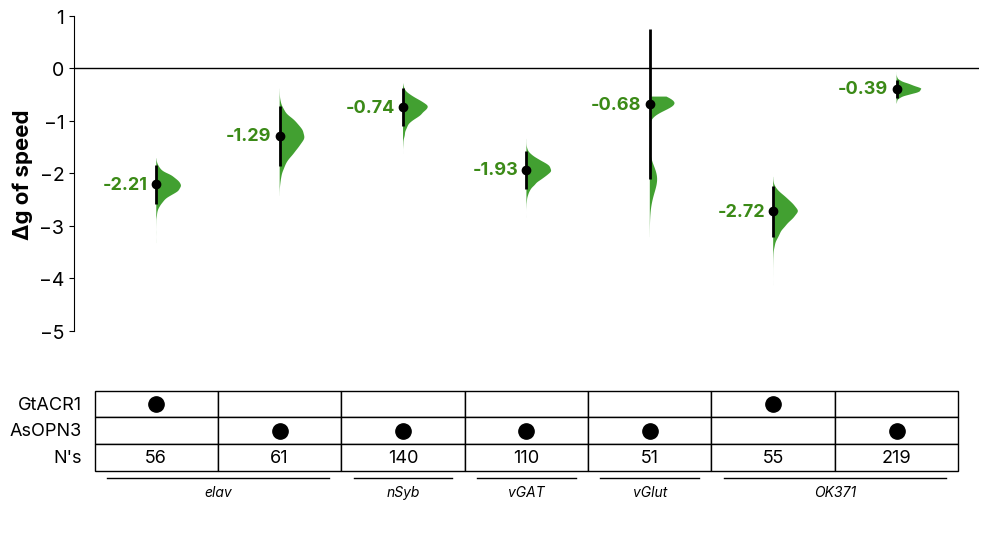

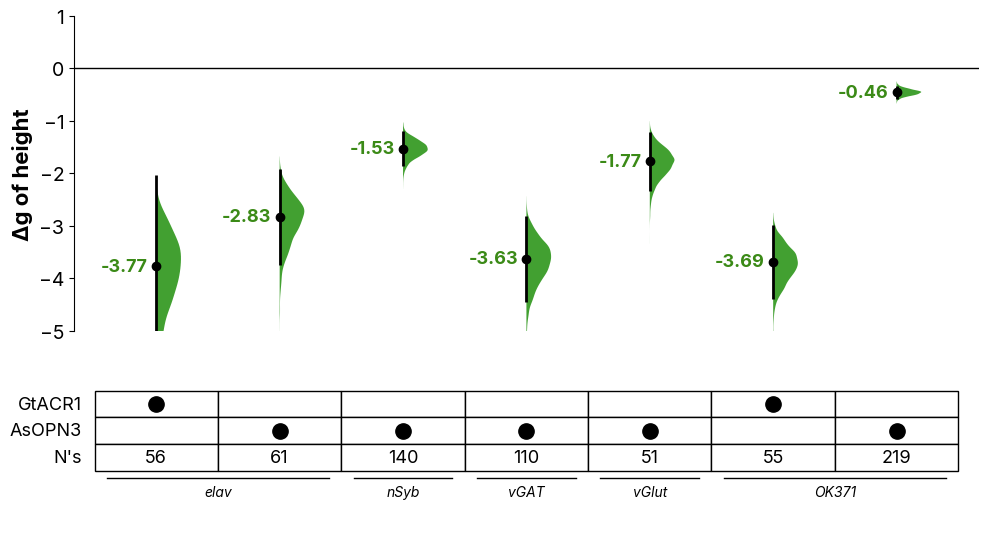

In [15]:
# Generate paired phase plots with TABLE format
lstnamings = ['speed', 'height']

##wt comparison
files_full = [f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 allstats_DARK_FULL.csv',           
              f'nSyb x eOPN3 allstats_DARK_FULL.csv',
              f'vGAT x eOPN3 allstats_DARK_FULL.csv', f'vGlut x eOPN3 allstats_DARK_FULL.csv',
              f'OK371 x ACR allstats_DARK_FULL.csv', f'OK371 x eOPN3 allstats_DARK_FULL.csv']

for n in lstnamings:
    # Process both phases
    dfmn_full, dfsmd_full = pergenotypeplotting_hedgesg(openPath, files_full, n)

    g_table = forestplot_single_phase_table(dfmn_full.replace("ACR", "GtACR1", regex = True), dfsmd_full.replace("ACR", "GtACR1", regex = True), "GtACR1", "AsOPN3")
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    #g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_table_single_phases_" + n + ".svg", bbox_inches="tight") 
    plt.show()
